In [ ]:
import os
dataset_path = "/content/drive/MyDrive/Colab Notebooks"
print("--- Daftar File di Drive  ---")
files = os.listdir(dataset_path)
for f in files:
    if f.endswith('.npy') or f.endswith('.joblib'):
        print(f"- {f}")

--- Daftar File di Drive Kamu ---
- train_benign_clean.npy
- dataset_split.joblib


[INFO] Memuat dataset dari Drive...
[INFO] Data siap! Melatih model pada 11296017 baris...


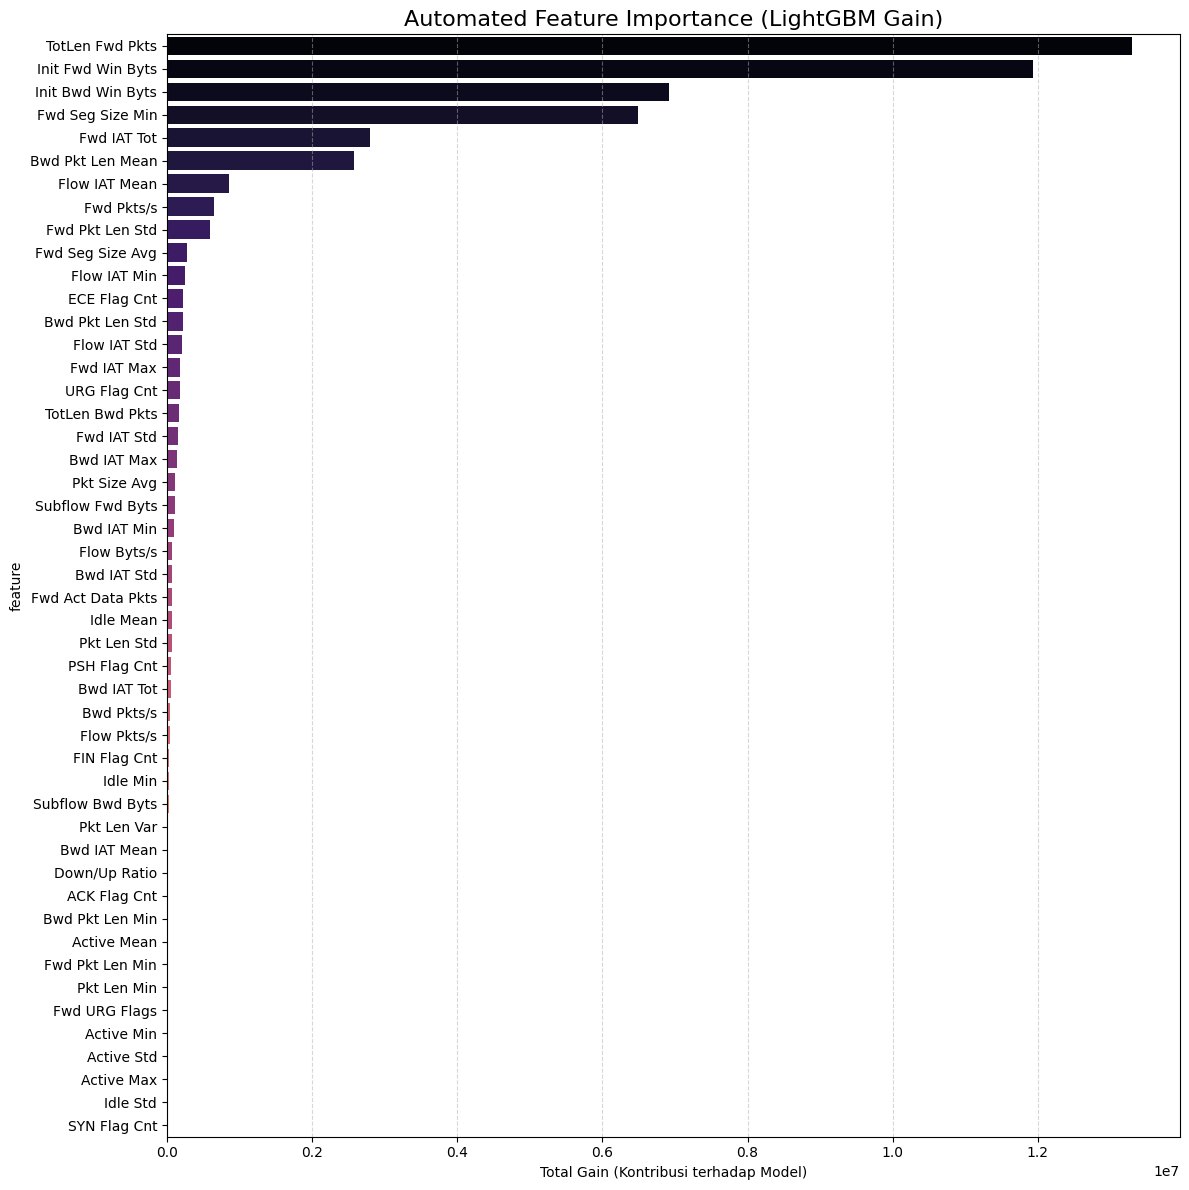


--- HASIL DETEKSI OTOMATIS ---
Total fitur yang dianalisis: 48
Fitur yang terdeteksi 'Loyo/Toxic' (Importance <= 13293.95):
['Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt', 'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min', 'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max', 'Idle Std', 'SYN Flag Cnt']


In [ ]:
import joblib
import os
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("[INFO] Memuat dataset dari Drive...")
data = joblib.load(split_file)

X_train = data['X_train']
y_train = data['y_train']
features = data['features']

print(f"[INFO] Data siap! Melatih model pada {X_train.shape[0]} baris...")

train_data = lgb.Dataset(X_train, label=y_train, feature_name=features)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42
}

lgbm_model = lgb.train(params, train_data, num_boost_round=100)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': lgbm_model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

threshold = importance_df['importance'].max() * 0.001
toxic_auto = importance_df[importance_df['importance'] <= threshold]

plt.figure(figsize=(12, 12))
sns.barplot(x='importance', y='feature', data=importance_df, palette='magma', hue='feature', legend=False)
plt.title('Automated Feature Importance (LightGBM Gain)', fontsize=16)
plt.xlabel('Total Gain (Kontribusi terhadap Model)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n--- HASIL DETEKSI OTOMATIS ---")
print(f"Total fitur yang dianalisis: {len(features)}")
print(f"Fitur yang terdeteksi 'Loyo/Toxic' (Importance <= {threshold:.2f}):")
print(toxic_auto['feature'].tolist())

In [ ]:
import joblib, os, gc
import numpy as np
from sklearn.utils import class_weight

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("[INFO] Memuat ulang dataset_split.joblib...")
data = joblib.load(split_file)

feat_names = data['features']
toxic = [
    'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
    'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
    'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
    'Idle Std', 'SYN Flag Cnt'
]

healthy_idx = [i for i, f in enumerate(feat_names) if f not in toxic]
healthy_names = [f for f in feat_names if f not in toxic]

print(f"[INFO] Menghapus {len(toxic)} fitur toxic...")
print(f"[INFO] Menggunakan {len(healthy_idx)} fitur sehat...")

X_train = data['X_train'][:, healthy_idx].astype('float32')
y_train = data['y_train']

X_val = data['X_val'][:, healthy_idx].astype('float32')
y_val = data['y_val']

X_test = data['X_test'][:, healthy_idx].astype('float32')
y_test = data['y_test']

del data
gc.collect()

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

print("\n" + "="*55)
print(f"DATA READY")
print("="*55)
print(f"Jumlah Fitur Final : {X_train.shape[1]}")
print(f"Data Training      : {X_train.shape[0]:,} baris")
print(f"Data Validation    : {X_val.shape[0]:,} baris")
print(f"Data Testing       : {X_test.shape[0]:,} baris")
print(f"Bobot Kelas        : {class_weights}")
print("="*55)

[INFO] Memuat ulang dataset_split.joblib...
[INFO] Menghapus 14 fitur toxic...
[INFO] Menggunakan 34 fitur sehat...

DATA READY
Jumlah Fitur Final : 34
Data Training      : 11,296,017 baris
Data Validation    : 2,420,575 baris
Data Testing       : 2,420,576 baris
Bobot Kelas        : {0: np.float64(0.6025723120359691), 1: np.float64(2.937304912385444)}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_mlp(input_dim):
    model = models.Sequential([
        # 1. Input Layer
        layers.Input(shape=(input_dim,)),

        # 2. Hidden Layer 1
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # 3. Hidden Layer 2
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # 4. Hidden Layer 3
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),

        # 5. Output Layer
        layers.Dense(1, activation='sigmoid')
    ], name="MLP_IDS_2018_v2")

    opt = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc', curve='PR')
        ]
    )
    return model

final_input_dim = X_train.shape[1]
mlp_model = build_mlp(input_dim=final_input_dim)

mlp_model.summary()

Model: "MLP_IDS_2018_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=4,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

checkpoint = ModelCheckpoint(
    os.path.join(dataset_path, 'best_mlp_model_v2.keras'),
    save_best_only=True,
    monitor='val_auc',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

print("Memulai Training MLP...")

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8192,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Memulai Training MLP...
Epoch 1/30
1379/1379 ━━━━━━━━━━━━━━━━━━━━ 100s 69ms/step - accuracy: 0.9766 - auc: 0.9657 - loss: 0.1251 - recall: 0.9406 - val_accuracy: 0.9846 - val_auc: 0.9720 - val_loss: 0.0785 - val_recall: 0.9530 - learning_rate: 0.0010
Epoch 2/30
1379/1379 ━━━━━━━━━━━━━━━━━━━━ 95s 68ms/step - accuracy: 0.9850 - auc: 0.9723 - loss: 0.1010 - recall: 0.9521 - val_accuracy: 0.9853 - val_auc: 0.9737 - val_loss: 0.0750 - val_recall: 0.9533 - learning_rate: 0.0010
Epoch 3/30
1379/1379 ━━━━━━━━━━━━━━━━━━━━ 141s 67ms/step - accuracy: 0.9854 - auc: 0.9731 - loss: 0.0989 - recall: 0.9527 - val_accuracy: 0.9859 - val_auc: 0.9740 - val_loss: 0.0728 - val_recall: 0.9531 - learning_rate: 0.0010
Epoch 4/30
1379/1379 ━━━━━━━━━━━━━━━━━━━━ 144s 68ms/step - accuracy: 0.9857 - auc: 0.9734 - loss: 0.0979 - recall: 0.9528 - val_accuracy: 0.9857 - val_auc: 0.9743 - val_loss: 0.0751 - val_recall: 0.9532 - learning_rate: 0.0010
Epoch 5/30
1379/1379 ━━━━━━━━━━━━━━━━━━━━ 140s 67ms/step - accuracy: 

[INFO] Melakukan prediksi pada data test...
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step

==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

      Benign     0.9906    0.9939    0.9923   2008536
      Attack     0.9698    0.9542    0.9619    412040

    accuracy                         0.9871   2420576
   macro avg     0.9802    0.9740    0.9771   2420576
weighted avg     0.9871    0.9871    0.9871   2420576



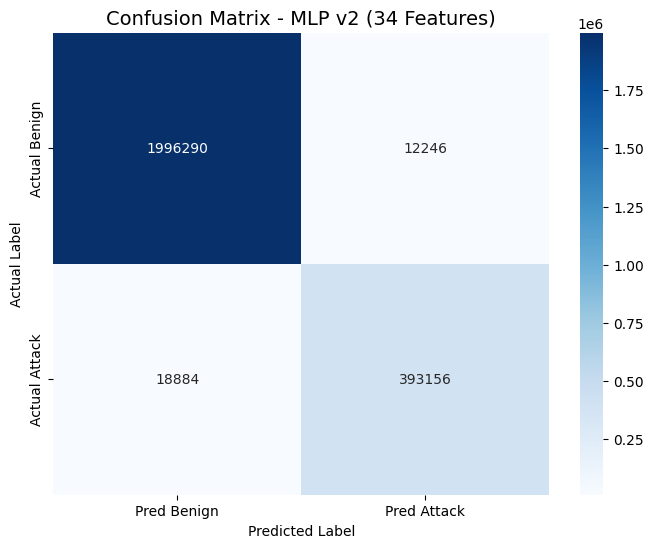

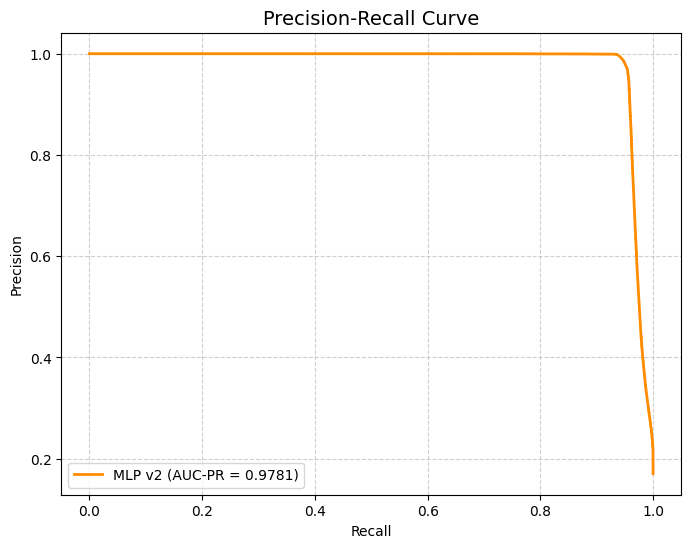

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc

# 1. Prediksi pada Data Test
print("[INFO] Melakukan prediksi pada data test...")
y_pred_prob = mlp_model.predict(X_test, batch_size=16384)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2.Classification Report
print("\n" + "="*20 + " CLASSIFICATION REPORT " + "="*20)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack'], digits=4))

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Confusion Matrix - MLP v2 (34 Features)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Visualisasi Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'MLP v2 (AUC-PR = {pr_auc:.4f})', color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp / (fp + tn)
specificity = tn / (tn + fp)

print("="*30)
print(f"HASIL ANALISIS ERROR (FPR)")
print("="*30)
print(f"True Negatives (TN)  : {tn:,}")
print(f"False Positives (FP) : {fp:,}")
print(f"False Negative (FN)  : {fn:,}")
print(f"True Positive (TP)   : {tp:,}")
print("-" * 30)
print(f"FPR (False Positive Rate) : {fpr:.6f} ({fpr*100:.4f}%)")
print(f"Specificity (TNR)        : {specificity:.6f} ({specificity*100:.4f}%)")
print("="*30)

HASIL ANALISIS ERROR (FPR)
True Negatives (TN)  : 1,996,290
False Positives (FP) : 12,246
False Negative (FN)  : 18,884
True Positive (TP)   : 393,156
------------------------------
FPR (False Positive Rate) : 0.006097 (0.6097%)
Specificity (TNR)        : 0.993903 (99.3903%)


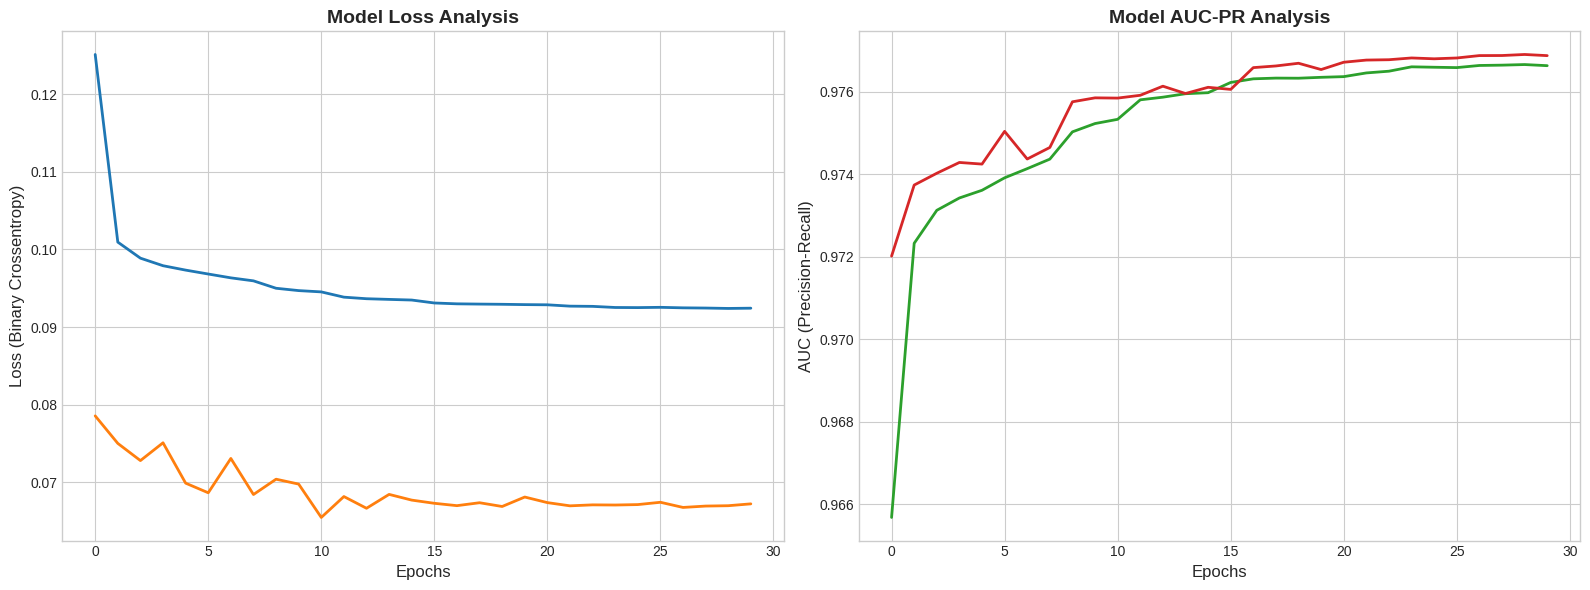

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_auc = history.history['val_auc'][best_epoch]

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFIK LOSS ---
ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', lw=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
ax1.set_title('Model Loss Analysis', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)


# --- GRAFIK AUC ---
ax2.plot(history.history['auc'], label='Training AUC', color='#2ca02c', lw=2)
ax2.plot(history.history['val_auc'], label='Validation AUC', color='#d62728', lw=2)
ax2.set_title('Model AUC-PR Analysis', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('AUC (Precision-Recall)', fontsize=12)


plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import recall_score

recall_attack = recall_score(y_test, y_pred)
recall_benign = recall_score(y_test, y_pred, pos_label=0)

print("--- VERIFIKASI KEBENARAN MODEL (BINARY) ---")
print(f"Detection Rate Attack (Semua Jenis): {recall_attack*100:.2f}%")
print(f"Detection Rate Benign (Specificity): {recall_benign*100:.2f}%")

--- VERIFIKASI KEBENARAN MODEL (BINARY) ---
Detection Rate Attack (Semua Jenis): 95.42%
Detection Rate Benign (Specificity): 99.39%


In [ ]:
def predict_network_test(data_point):

    input_data = data_point.reshape(1, -1).astype('float32')
    prediction_prob = mlp_model.predict(input_data, verbose=0)
    if prediction_prob >= 0.5:
        hasil_label = "ATTACK"
        confidence = prediction_prob[0][0]
    else:
        hasil_label = "BENIGN"
        confidence = 1 - prediction_prob[0][0]

    return hasil_label, confidence

index_contoh = 100
data_baru = X_test[index_contoh]
label_asli = "Attack" if y_test[index_contoh] == 1 else "Benign"

hasil, skor = predict_network_test(data_baru)

print(f"Data ke-{index_contoh} (Label Asli: {label_asli})")
print(f"Hasil Prediksi AI : {hasil}")
print(f"Tingkat Keyakinan : {skor*100:.2f}%")

Data ke-100 (Label Asli: Attack)
Hasil Prediksi AI : ATTACK
Tingkat Keyakinan : 99.99%


In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

print("[INFO] Melatih modul deteksi anomali (Isolation Forest)...")
X_benign_train = X_train[y_train == 0]
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
iso_forest.fit(X_benign_train)

def zero_day_detector(data_point):
    prob = mlp_model.predict(data_point.reshape(1, -1), verbose=0)[0][0]
    mlp_label = "ATTACK" if prob >= 0.5 else "BENIGN"
    is_normal = iso_forest.predict(data_point.reshape(1, -1))[0]

    status = "Aman"
    if mlp_label == "BENIGN" and is_normal == -1:
        status = "POTENSI ZERO-DAY)"
    elif mlp_label == "ATTACK":
        status = "SERANGAN TERDETEKSI (Known Attack)"
    else:
        status = "TRAFIK NORMAL"

    return status, prob, is_normal

# --- TEST SIMULASI ---
idx = 100
test_data = X_test[idx]
hasil, p_score, anomaly_score = zero_day_detector(test_data)

print(f"Hasil Analisis : {hasil}")
print(f"MLP Probability: {p_score:.4f}")
print(f"Anomaly Score  : {'Aneh' if anomaly_score == -1 else 'Normal'}")

[INFO] Melatih modul deteksi anomali (Isolation Forest)...
Hasil Analisis : SERANGAN TERDETEKSI (Known Attack)
MLP Probability: 0.9999
Anomaly Score  : Normal


In [ ]:
print("data untuk mencari potensi Zero-Day...")
indices = np.random.choice(len(X_test), 1000, replace=False)
zero_day_candidates = []

for idx in indices:
    status, p_score, anomaly_score = zero_day_detector(X_test[idx])
    if "ZERO-DAY" in status:
        zero_day_candidates.append({
            'Index': idx,
            'MLP_Prob': p_score,
            'Anomaly': 'Aneh (Outlier)',
            'Actual_Label': "Attack" if y_test[idx] == 1 else "Benign"
        })

if zero_day_candidates:
    print(f" Ditemukan {len(zero_day_candidates)} kandidat Zero-Day!")
    print(pd.DataFrame(zero_day_candidates))
else:
    print("Belum ditemukan Zero-Day di sampel ini.")

data untuk mencari potensi Zero-Day...
 Ditemukan 6 kandidat Zero-Day!
     Index      MLP_Prob         Anomaly Actual_Label
0   336470  4.074797e-02  Aneh (Outlier)       Benign
1  2325519  1.504667e-02  Aneh (Outlier)       Benign
2  1151657  1.074520e-08  Aneh (Outlier)       Benign
3   229841  1.374701e-02  Aneh (Outlier)       Benign
4  1050077  5.273327e-03  Aneh (Outlier)       Benign
5    31404  6.549708e-02  Aneh (Outlier)       Benign


In [ ]:
print("Melakukan penyisiran total pada data Test...")

y_pred_prob = mlp_model.predict(X_test, batch_size=16384, verbose=0)
y_pred_idx = (y_pred_prob > 0.5).astype(int).flatten()

missed_by_mlp = np.where((y_test == 1) & (y_pred_idx == 0))[0]

print(f"Total serangan yang lolos dari MLP: {len(missed_by_mlp)} data.")

if len(missed_by_mlp) > 0:
    print("Checking if Anomaly Detector can catch them...")

    saved_count = 0
    sample_saved = []

    for idx in missed_by_mlp:
        is_normal = iso_forest.predict(X_test[idx].reshape(1, -1))[0]
        if is_normal == -1:
            saved_count += 1
            if len(sample_saved) < 5:
                sample_saved.append({
                    'Index': idx,
                    'MLP_Prob': f"{y_pred_prob[idx][0]:.4f}",
                    'Anomaly': 'Outlier',
                    'Actual': 'ATTACK'
                })

    print(f"HASIL: Dari {len(missed_by_mlp)} serangan yang lolos, {saved_count} berhasil dideteksi sebagai ANOMALI!")
    if sample_saved:
        print("\n--- TABEL ---")
        print(pd.DataFrame(sample_saved).to_string(index=False))
else:
    print("Tidak ada serangan yang lolos dari MLP di dataset ini.")

Melakukan penyisiran total pada data Test...
Total serangan yang lolos dari MLP: 18884 data.
Checking if Anomaly Detector can catch them...
HASIL: Dari 18884 serangan yang lolos, 195 berhasil dideteksi sebagai ANOMALI!

--- TABEL ---
 Index MLP_Prob Anomaly Actual
 10378   0.1016 Outlier ATTACK
 20475   0.0622 Outlier ATTACK
 28769   0.0413 Outlier ATTACK
 29084   0.0637 Outlier ATTACK
 59681   0.0713 Outlier ATTACK
